1번 문제
========
1. num_1 폴더의 uriage 파일을 pandas를 이용하여 데이터프레임으로 불러온다. 
2. purchase_date 컬럼의 데이터 타입을 datetime을 변경한다. 
3. item_name 컬럼의 값을 대문자로 변경한다. 
4. item_name 컬럼의 공백을 지워준다. 
5. item_name 컬럼을 기준으로 오름차순 정렬한다. 
6. 데이터의 결측치가 존재하는지 확인한다. 
7. item_price 컬럼의 결측치의 값을 해당하는 item_name의 맥스값으로 치환하여 준다. 

In [133]:
import pandas as pd
import numpy as np

In [134]:
num_1_df=pd.read_csv('C:/Users/jangd/OneDrive/사진/문서/GitHub/git_hub_0420/problem/num_1/uriage.csv') 

# 1.num_1 폴더의 uriage 파일을 pandas를 이용하여 데이터프레임으로 불러온다. 

In [135]:
num_1_df # 

,purchase_date,item_name,item_price,customer_name
0,2019-06-13 18:02,상품A,100.0,김가온
1,2019-07-13 13:05,상 품 S,NaN,김우찬
2,2019-05-11 19:42,상 품 a,NaN,김유찬
3,2019-02-12 23:40,상품Z,2600.0,김재현
4,2019-04-22 3:09,상품a,NaN,김강현
...,...,...,...,...
2994,2019-02-15 2:56,상품Y,2500.0,김정민
2995,2019-06-22 4:03,상품M,1300.0,김재원
2996,2019-03-29 11:14,상품Q,NaN,김지율
2997,2019-07-14 12:56,상품H,NaN,김승주


In [136]:
num_1_df.groupby(['item_name']).max()

,purchase_date,item_price,customer_name
item_name,,,
상 품 n,2019-01-02 13:26,1400.0,김범준
상품 E,2019-03-02 15:38,500.0,김시율
상품 M,2019-03-02 1:53,1300.0,김동건
상품 P,2019-03-04 16:39,1600.0,김승윤
상품 S,2019-05-03 1:15,1900.0,김동현
...,...,...,...
상품s,2019-04-24 14:12,1900.0,김현성
상품t,2019-02-28 15:15,2000.0,김성민
상품v,2019-02-18 8:16,2200.0,김연호


In [137]:
max(num_1_df["item_name"])

'상품y'

In [138]:
num_1_df['purchase_date'] = pd.to_datetime(num_1_df['purchase_date']) 
# 2. purchase_date 컬럼의 데이터 타입을 datetime을 변경한다. 

In [139]:
num_1_df['item_name']=num_1_df['item_name'].str.upper()  # object형이라서 str형으로 바꿔줘야한다.
# 3. item_name 컬럼의 값을 대문자로 변경한다. 


In [140]:
# a=[]
# for i in list(num_1_df['item_name']):
#     i=i.replace(" ", "") # str을 넣고 replace를 했어야 했음
#     i=" ".join(i.split())
#     a.append(i)
    
# num_1_df['item_name']=a
# num_1_df
# 4. item_name 컬럼의 공백을 지워준다. 
num_1_df['item_name']=num_1_df['item_name'].str.replace(" ","")
num_1_df['item_name']=num_1_df['item_name']

In [141]:
# 5. item_name 컬럼을 기준으로 오름차순 정렬한다. 
num_1_df.sort_values(by=['item_name'])

,purchase_date,item_name,item_price,customer_name
0,2019-06-13 18:02:00,상품A,100.0,김가온
1748,2019-05-19 20:22:00,상품A,100.0,김시훈
223,2019-06-25 08:13:00,상품A,100.0,김유진
1742,2019-06-13 16:03:00,상품A,100.0,김건희
1738,2019-02-10 00:28:00,상품A,100.0,김하랑
...,...,...,...,...
2880,2019-04-22 00:36:00,상품Y,NaN,김동욱
2881,2019-04-30 14:21:00,상품Y,NaN,김하준
1525,2019-01-24 10:27:00,상품Y,2500.0,김범준
1361,2019-05-28 13:45:00,상품Y,2500.0,김수현


In [142]:
num_1_df.isnull().sum()

purchase_date      0
item_name          0
item_price       387
customer_name      0
dtype: int64

In [143]:
# #7. item_price 컬럼의 결측치의 값을 해당하는 item_name의 맥스값으로 치환하여 준다. 
# from string import ascii_uppercase
# # condition1 = (num_1_df['item_name'] =='상품A')
# # condition2 = (num_1_df['item_price'].isnull())
# # num_1_df.loc[condition1 & condition2]

# alpha_list = list(ascii_uppercase)
# a=[]
# for i in alpha_list:
#     a.append("상품"+i)
# a
# for j in range(25):
#     condition1 = (num_1_df['item_name'] ==a[j])
#     condition2 = (num_1_df['item_price'].isnull())
#     num_1_df.loc[condition1 & condition2]=num_1_df.loc[('item_name'=a[j])]

fig_is_null=num_1_df["item_price"].isnull()


for frg in list(num_1_df.loc[fig_is_null,"item_name"].unique()): # unique는 중복값 다삭제 
    price=num_1_df.loc[(~fig_is_null)&(num_1_df["item_name"]==frg),"item_price"].max() # 최대값나오게하기
    num_1_df["item_price"].loc[(fig_is_null)&(num_1_df["item_name"]==frg)]=price #결측치 채우기
    
num_1_df

C:\Users\jangd\AppData\Local\Temp\ipykernel_20252\574729764.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  num_1_df["item_price"].loc[(fig_is_null)&(num_1_df["item_name"]==frg)]=price #결측치 채우기


,purchase_date,item_name,item_price,customer_name
0,2019-06-13 18:02:00,상품A,100.0,김가온
1,2019-07-13 13:05:00,상품S,1900.0,김우찬
2,2019-05-11 19:42:00,상품A,100.0,김유찬
3,2019-02-12 23:40:00,상품Z,2600.0,김재현
4,2019-04-22 03:09:00,상품A,100.0,김강현
...,...,...,...,...
2994,2019-02-15 02:56:00,상품Y,2500.0,김정민
2995,2019-06-22 04:03:00,상품M,1300.0,김재원
2996,2019-03-29 11:14:00,상품Q,1700.0,김지율
2997,2019-07-14 12:56:00,상품H,800.0,김승주


In [144]:
num_1_dfx = num_1_df.groupby("item_name").max("item_price")
price_dict = num_1_dfx["item_price"].to_dict()

for i, dt in enumerate(num_1_df["item_price"]) :
    k = price_dict[num_1_df["item_name"].iloc[i]]
    print(k)
    if dt == pd.notnull :
        continue
    else :
        num_1_df["item_price"].iloc[i] = k

100.0
1900.0
100.0
2600.0
100.0
1900.0
100.0
2200.0
1500.0
100.0
2100.0
1200.0
2200.0
1500.0


C:\Users\jangd\AppData\Local\Temp\ipykernel_20252\587303477.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  num_1_df["item_price"].iloc[i] = k


100.0
300.0
2200.0
900.0
1800.0
2400.0
1500.0
700.0
2400.0
1800.0
1600.0
1700.0
2500.0
1600.0
1600.0
1800.0
1600.0
100.0
1400.0
1800.0
2300.0
100.0
500.0
1100.0
1500.0
2300.0
1500.0
1100.0
200.0
600.0
1600.0
2400.0
200.0
1900.0
600.0
2400.0
2300.0
1400.0
1700.0
1600.0
900.0
600.0
400.0
1800.0
1300.0
1300.0
1700.0
100.0
2500.0
900.0
2100.0
800.0
1600.0
1600.0
2000.0
2500.0
2300.0
1300.0
2200.0
400.0
1000.0
1500.0
1200.0
600.0
2100.0
1400.0
1600.0
1900.0
2400.0
1500.0
2200.0
1100.0
1400.0
900.0
1500.0
1800.0
2200.0
2500.0
500.0
500.0
800.0
1900.0
2300.0
2500.0
1500.0
600.0
1100.0
200.0
2300.0
1700.0
1700.0
1400.0
1900.0
1300.0
900.0
2000.0
900.0
800.0
2500.0
1800.0
300.0
2200.0
2000.0
100.0
2000.0
1700.0
1600.0
2300.0
900.0
2000.0
700.0
1400.0
2100.0
1900.0
2100.0
1300.0
100.0
1600.0
2100.0
2400.0
900.0
2100.0
2400.0
1200.0
600.0
700.0
400.0
2400.0
2100.0
1400.0
300.0
2300.0
1900.0
2100.0
1100.0
700.0
1700.0
900.0
1200.0
2000.0
1600.0
2000.0
2200.0
500.0
1600.0
700.0
1200.0
1600.0
1300.0

In [145]:
# print(num_1_dfx)
# print(price_dict)
# num_1_df
# price_dict
num_1_df["item_price"]

0        100.0
1       1900.0
2        100.0
3       2600.0
4        100.0
         ...  
2994    2500.0
2995    1300.0
2996    1700.0
2997     800.0
2998     400.0
Name: item_price, Length: 2999, dtype: float64

2번 문제 
===========

1. transaction 폴더 내에 있는 csv 파일을 모두 데이터프렘으로 불러온다. 
2. transaction_1과 transaction_2를 유니언 결합을 한다. 
3. transaction_detail_1과 transaction_detail_2를 유니언 결합을 한다. 
4. 2,3 번의 데이터프레임의 값을 조인 결합을 한다. 
5. 4번 작업한 데이터프레임을 customer_master, item_master 와 조인 결합한다. 
6. quantity와 item_price의 곱한 값으로 price라는 컬럼을 생성한다. 
7. payment_date컬럼의 데이터형태를 datetime으로 변경한다. 
8. payment_date값의 년 월값만 추출하여 payment_month 컬럼을 생성한다. 
9. groupby를 이용하여 월별, 상품별 price와 quantity의 합계를 출력한다. 


In [146]:
#1. transaction 폴더 내에 있는 csv 파일을 모두 데이터프렘으로 불러온다.
custom=pd.read_csv('C:/Users/jangd/OneDrive/사진/문서/GitHub/git_hub_0420/problem/num_2/customer_master.csv') 
item_master=pd.read_csv('C:/Users/jangd/OneDrive/사진/문서/GitHub/git_hub_0420/problem/num_2/item_master.csv') 
trans_1=pd.read_csv('C:/Users/jangd/OneDrive/사진/문서/GitHub/git_hub_0420/problem/num_2/transaction_1.csv')
trans_2=pd.read_csv('C:/Users/jangd/OneDrive/사진/문서/GitHub/git_hub_0420/problem/num_2/transaction_2.csv')
trans_de_1=pd.read_csv('C:/Users/jangd/OneDrive/사진/문서/GitHub/git_hub_0420/problem/num_2/transaction_detail_1.csv')
trans_de_2=pd.read_csv('C:/Users/jangd/OneDrive/사진/문서/GitHub/git_hub_0420/problem/num_2/transaction_detail_2.csv') 

In [147]:
# 2. transaction_1과 transaction_2를 유니언 결합을 한다. 
union=pd.concat([trans_1,trans_2])
union

,transaction_id,price,payment_date,customer_id
0,T0000000113,210000,2019-02-01 01:36:57,PL563502
1,T0000000114,50000,2019-02-01 01:37:23,HD678019
2,T0000000115,120000,2019-02-01 02:34:19,HD298120
3,T0000000116,210000,2019-02-01 02:47:23,IK452215
4,T0000000117,170000,2019-02-01 04:33:46,PL542865
...,...,...,...,...
1781,T0000006894,180000,2019-07-31 21:20:44,HI400734
1782,T0000006895,85000,2019-07-31 21:52:48,AS339451
1783,T0000006896,100000,2019-07-31 23:35:25,OA027325
1784,T0000006897,85000,2019-07-31 23:39:35,TS624738


In [148]:
# 3. transaction_detail_1과 transaction_detail_2를 유니언 결합을 한다. 
union_de=pd.concat([trans_de_1,trans_de_2])
union_de

,detail_id,transaction_id,item_id,quantity
0,0,T0000000113,S005,1
1,1,T0000000114,S001,1
2,2,T0000000115,S003,1
3,3,T0000000116,S005,1
4,4,T0000000117,S002,2
...,...,...,...,...
2139,7139,T0000006894,S004,1
2140,7140,T0000006895,S002,1
2141,7141,T0000006896,S001,2
2142,7142,T0000006897,S002,1


In [149]:
# 4. 2,3 번의 데이터프레임의 값을 조인 결합을 한다. 
all_union=union.join(union_de.set_index('transaction_id'), on = 'transaction_id')
all_union


,transaction_id,price,payment_date,customer_id,detail_id,item_id,quantity
0,T0000000113,210000,2019-02-01 01:36:57,PL563502,0,S005,1
1,T0000000114,50000,2019-02-01 01:37:23,HD678019,1,S001,1
2,T0000000115,120000,2019-02-01 02:34:19,HD298120,2,S003,1
3,T0000000116,210000,2019-02-01 02:47:23,IK452215,3,S005,1
4,T0000000117,170000,2019-02-01 04:33:46,PL542865,4,S002,2
...,...,...,...,...,...,...,...
1781,T0000006894,180000,2019-07-31 21:20:44,HI400734,7139,S004,1
1782,T0000006895,85000,2019-07-31 21:52:48,AS339451,7140,S002,1
1783,T0000006896,100000,2019-07-31 23:35:25,OA027325,7141,S001,2
1784,T0000006897,85000,2019-07-31 23:39:35,TS624738,7142,S002,1


In [150]:
custom


,customer_id,customer_name,registration_date,email,gender,age,birth,pref
0,IK152942,김서준,2019-01-01 0:25,hirata_yuujirou@example.com,M,29,1990-06-10,대전광역시
1,TS808488,김예준,2019-01-01 1:13,tamura_shiori@example.com,F,33,1986-05-20,인천광역시
2,AS834628,김도윤,2019-01-01 2:00,hisano_yuki@example.com,F,63,1956-01-02,광주광역시
3,AS345469,김시우,2019-01-01 4:48,tsuruoka_kaoru@example.com,M,74,1945-03-25,인천광역시
4,GD892565,김주원,2019-01-01 4:54,oouchi_takashi@example.com,M,54,1965-08-05,울산광역시
...,...,...,...,...,...,...,...,...
4995,AS677229,정우석,2019-07-31 16:52,hirayama_risa@example.com,F,77,1941-10-17,대전광역시
4996,HD758694,정영훈,2019-07-31 19:09,nakahara_mahiru@example.com,F,27,1991-11-13,광주광역시
4997,PL538517,정준기,2019-07-31 19:30,tabata_yuu1@example.com,F,73,1945-12-28,대전광역시
4998,OA955088,정도형,2019-07-31 22:32,setouchi_hikaru@example.com,F,75,1944-04-09,부산광역시


In [151]:
# 5. 4번에서 작업한 데이터프레임을 customer_master, item_master 와 조인 결합한다.
all_union_2=all_union.join(item_master.set_index('item_id'), on = 'item_id')
all_union_2
all_union_3=all_union_2.join(custom.set_index('customer_id'), on = 'customer_id')
all_union_3
# 데이터베이스들은 보통 컬럼값이 많을수록 더 용량이 큼

,transaction_id,price,payment_date,customer_id,detail_id,item_id,quantity,item_name,item_price,customer_name,registration_date,email,gender,age,birth,pref
0,T0000000113,210000,2019-02-01 01:36:57,PL563502,0,S005,1,PC-E,210000,김태경,2019-01-07 14:34,imoto_yoshimasa@example.com,M,30,1989-07-15,대전광역시
1,T0000000114,50000,2019-02-01 01:37:23,HD678019,1,S001,1,PC-A,50000,김영웅,2019-01-27 18:00,mifune_rokurou@example.com,M,73,1945-11-29,서울특별시
2,T0000000115,120000,2019-02-01 02:34:19,HD298120,2,S003,1,PC-C,120000,김강현,2019-01-11 8:16,yamane_kogan@example.com,M,42,1977-05-17,광주광역시
3,T0000000116,210000,2019-02-01 02:47:23,IK452215,3,S005,1,PC-E,210000,김주한,2019-01-10 5:07,ikeda_natsumi@example.com,F,47,1972-03-17,인천광역시
4,T0000000117,170000,2019-02-01 04:33:46,PL542865,4,S002,2,PC-B,85000,김영빈,2019-01-25 6:46,kurita_kenichi@example.com,M,74,1944-12-17,광주광역시
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1781,T0000006894,180000,2019-07-31 21:20:44,HI400734,7139,S004,1,PC-D,180000,김윤성,2019-01-04 13:24,shishido_akira@example.com,M,64,1955-01-13,대구광역시
1782,T0000006895,85000,2019-07-31 21:52:48,AS339451,7140,S002,1,PC-B,85000,김무경,2019-02-11 19:34,aihara_miki@example.com,F,74,1945-02-03,대구광역시
1783,T0000006896,100000,2019-07-31 23:35:25,OA027325,7141,S001,2,PC-A,50000,박준석,2019-04-17 9:23,matsuda_saki@example.com,F,40,1979-05-25,서울특별시
1784,T0000006897,85000,2019-07-31 23:39:35,TS624738,7142,S002,1,PC-B,85000,이가빈,2019-02-20 18:15,shinndou_masatoshi@example.com,M,56,1963-02-21,인천광역시


In [152]:
#6. quantity와 item_price의 곱한 값으로 price라는 컬럼을 생성한다. 
all_union_3['price']=all_union_3['quantity']*all_union_3['item_price']
all_union_3

,transaction_id,price,payment_date,customer_id,detail_id,item_id,quantity,item_name,item_price,customer_name,registration_date,email,gender,age,birth,pref
0,T0000000113,210000,2019-02-01 01:36:57,PL563502,0,S005,1,PC-E,210000,김태경,2019-01-07 14:34,imoto_yoshimasa@example.com,M,30,1989-07-15,대전광역시
1,T0000000114,50000,2019-02-01 01:37:23,HD678019,1,S001,1,PC-A,50000,김영웅,2019-01-27 18:00,mifune_rokurou@example.com,M,73,1945-11-29,서울특별시
2,T0000000115,120000,2019-02-01 02:34:19,HD298120,2,S003,1,PC-C,120000,김강현,2019-01-11 8:16,yamane_kogan@example.com,M,42,1977-05-17,광주광역시
3,T0000000116,210000,2019-02-01 02:47:23,IK452215,3,S005,1,PC-E,210000,김주한,2019-01-10 5:07,ikeda_natsumi@example.com,F,47,1972-03-17,인천광역시
4,T0000000117,170000,2019-02-01 04:33:46,PL542865,4,S002,2,PC-B,85000,김영빈,2019-01-25 6:46,kurita_kenichi@example.com,M,74,1944-12-17,광주광역시
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1781,T0000006894,180000,2019-07-31 21:20:44,HI400734,7139,S004,1,PC-D,180000,김윤성,2019-01-04 13:24,shishido_akira@example.com,M,64,1955-01-13,대구광역시
1782,T0000006895,85000,2019-07-31 21:52:48,AS339451,7140,S002,1,PC-B,85000,김무경,2019-02-11 19:34,aihara_miki@example.com,F,74,1945-02-03,대구광역시
1783,T0000006896,100000,2019-07-31 23:35:25,OA027325,7141,S001,2,PC-A,50000,박준석,2019-04-17 9:23,matsuda_saki@example.com,F,40,1979-05-25,서울특별시
1784,T0000006897,85000,2019-07-31 23:39:35,TS624738,7142,S002,1,PC-B,85000,이가빈,2019-02-20 18:15,shinndou_masatoshi@example.com,M,56,1963-02-21,인천광역시


In [153]:
# payment_date컬럼의 데이터형태를 datetime으로 변경한다. 

all_union_3['payment_date']=pd.to_datetime(all_union_3['payment_date'])
# all_union_3.info()

In [154]:
# 8. payment_date값의 년 월값만 추출하여 payment_month 컬럼을 생성한다. 
# all_union_3['payment_date']
# all_union_3['payment_month'] = str(all_union_3['payment_date'].dt.year)+str(all_union_3['payment_date'].dt.month)
all_union_3['payment_month']=all_union_3['payment_date'].dt.strftime("%Y "+"%m")
all_union_3

,transaction_id,price,payment_date,customer_id,detail_id,item_id,quantity,item_name,item_price,customer_name,registration_date,email,gender,age,birth,pref,payment_month
0,T0000000113,210000,2019-02-01 01:36:57,PL563502,0,S005,1,PC-E,210000,김태경,2019-01-07 14:34,imoto_yoshimasa@example.com,M,30,1989-07-15,대전광역시,2019 02
1,T0000000114,50000,2019-02-01 01:37:23,HD678019,1,S001,1,PC-A,50000,김영웅,2019-01-27 18:00,mifune_rokurou@example.com,M,73,1945-11-29,서울특별시,2019 02
2,T0000000115,120000,2019-02-01 02:34:19,HD298120,2,S003,1,PC-C,120000,김강현,2019-01-11 8:16,yamane_kogan@example.com,M,42,1977-05-17,광주광역시,2019 02
3,T0000000116,210000,2019-02-01 02:47:23,IK452215,3,S005,1,PC-E,210000,김주한,2019-01-10 5:07,ikeda_natsumi@example.com,F,47,1972-03-17,인천광역시,2019 02
4,T0000000117,170000,2019-02-01 04:33:46,PL542865,4,S002,2,PC-B,85000,김영빈,2019-01-25 6:46,kurita_kenichi@example.com,M,74,1944-12-17,광주광역시,2019 02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1781,T0000006894,180000,2019-07-31 21:20:44,HI400734,7139,S004,1,PC-D,180000,김윤성,2019-01-04 13:24,shishido_akira@example.com,M,64,1955-01-13,대구광역시,2019 07
1782,T0000006895,85000,2019-07-31 21:52:48,AS339451,7140,S002,1,PC-B,85000,김무경,2019-02-11 19:34,aihara_miki@example.com,F,74,1945-02-03,대구광역시,2019 07
1783,T0000006896,100000,2019-07-31 23:35:25,OA027325,7141,S001,2,PC-A,50000,박준석,2019-04-17 9:23,matsuda_saki@example.com,F,40,1979-05-25,서울특별시,2019 07
1784,T0000006897,85000,2019-07-31 23:39:35,TS624738,7142,S002,1,PC-B,85000,이가빈,2019-02-20 18:15,shinndou_masatoshi@example.com,M,56,1963-02-21,인천광역시,2019 07


In [156]:
# 9. groupby를 이용하여 월별, 상품별 price와 quantity의 합계를 출력한다. 
# all_pr=all_union_3.groupby(['payment_month','item_name']).sum('price')
# all_quan=all_union_3.groupby(['payment_month','item_name']).sum('quantity')

all_union_3.groupby(["payment_month","item_name"]).sum()[['price','quantity']]


price  quantity
payment_month item_name                    
2019 02       PC-A       24150000       483
              PC-B       25245000       297
              PC-C       19800000       165
              PC-D       31140000       173
              PC-E       59850000       285
2019 03       PC-A       26000000       520
              PC-B       25500000       300
              PC-C       19080000       159
              PC-D       25740000       143
              PC-E       64050000       305
2019 04       PC-A       25900000       518
              PC-B       23460000       276
              PC-C       21960000       183
              PC-D       24300000       135
              PC-E       64890000       309
2019 05       PC-A       24850000       497
              PC-B       25330000       298
              PC-C       20520000       171
              PC-D       25920000       144
              PC-E       58800000       280
2019 06       PC-A       26000000       520
              PC-B       23970000       282
              PC-C       21840000       182
              PC-D       28800000       160
              PC-E       63420000       302
2019 07       PC-A       25250000       505
              PC-B       28220000       332
              PC-C       19440000       162
              PC-D       26100000       145
              PC-E       71610000       341

3번 문제
==========

1. num_3 폴더내의 drink 파일을 데이터프레임으로 불러온다. 
2. 대륙 컬럼인 continent 결측 데이터를 OT로 지정한다. 
3. 대륙별 spirit_servings의 평균, 최소, 최대, 합계를 계산한다. 
4. 전체 평균보다 많은 알코올 섭취하는 대륙을 구한다. 
5. 3번 과정의 데이터를 바그래프를 이용하여 시각화 한다. 

In [173]:
# 1. num_3 폴더내의 drink 파일을 데이터프레임으로 불러온다. 
dri=pd.read_csv('C:/Users/jangd/OneDrive/사진/문서/GitHub/git_hub_0420/problem/num_3/drinks.csv') 

In [175]:
# 대륙 컬럼인 continent 결측 데이터를 OT로 지정한다. 
dri['continent']=dri['continent'].fillna('OT')

In [182]:
#3. 대륙별 spirit_servings의 평균, 최소, 최대, 합계를 계산한다.

#모든열에 여러 함수를 매핑: group객체.agg([함수1,함수2,함수3...]
#각 열마다 다른 함수를 매핑: group객체 .agg('열1':함수1,'열2':함수)
sume=dri.groupby(['continent']).sum()
maxe=dri.groupby(['continent']).max()
mine=dri.groupby(['continent']).min()
meane=dri.groupby(['continent']).mean()
maxe
# result=dri.groupby('continent').spirit_servings.agg(['mean','min','max','sum'])  #agg 
# result

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
continent,,,,,
AF,Zimbabwe,376,152,233,9.1
AS,Yemen,247,326,123,11.5
EU,United Kingdom,361,373,370,14.4
OC,Vanuatu,306,254,212,10.4
OT,USA,285,438,100,11.9
SA,Venezuela,333,302,221,8.3


In [177]:
# 4. 전체 평균보다 많은 알코올 섭취하는 대륙을 구한다. 
con_me=dri.groupby(['continent']).mean('total_litres_of_pure_alcohol')

con_me.loc[(con_me.total_litres_of_pure_alcohol>=dri['total_litres_of_pure_alcohol'].mean(),"total_litres_of_pure_alcohol")]
# # dri['total_litres_of_pure_alcohol'].mean():


continent
EU    8.617778
OT    5.995652
SA    6.308333
Name: total_litres_of_pure_alcohol, dtype: float64

TypeError: can only concatenate list (not "float") to list

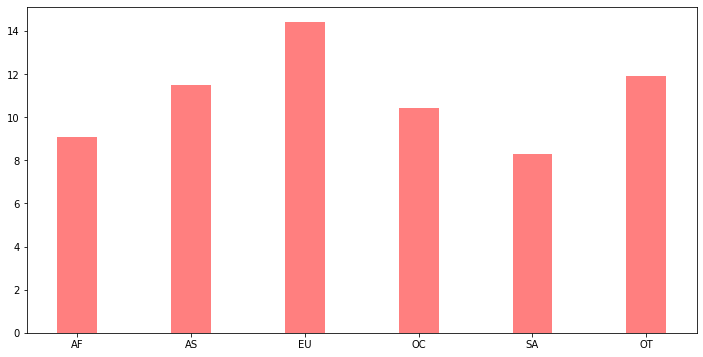

In [191]:
#5. 3번 과정의 데이터를 바그래프를 이용하여 시각화 한다. 
import matplotlib.pyplot as plt


maxe=[9.1,11.5,14.4,10.4,8.3,11.9]
sume=[159.4,95.5,387.8,54.1,75.7,137.9]
mine=[0.0,0.0,0.0,0.0,3.8,2.2]
meane=[3.007547,2.170455,8.617778,3.381250,6.308333,5.995652]
feature=['AF','AS','EU','OC','SA','OT']
bar_width = 0.35

alpha = 0.5

n = 1  # This is our first dataset (out of 2)
t = 2 # Number of dataset
d = 6 # Number of sets of bars
w = 0.8 # Width of each bar

df = [t*element + w*n for element in range(d)]

def create_x(t, w, n, d):
    return [t*x + w*n for x in range(d)]

# b1 = plt.bar(index, df['max'], bar_width,alpha=alpha, color='red', label='max')

# b2 = plt.bar(index+ bar_width , df['sum'], bar_width, alpha=alpha, color='blue', label='sum')

# b3 = plt.bar(index+ 2* bar_width , df['min'], bar_width, alpha=alpha, color='green', label='min')
# b4 = plt.bar(index+3 * bar_width , df['mean'], bar_width, alpha=alpha, color='orange', label='mean')

plt.show()